In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import warnings
import re

warnings.filterwarnings('ignore')

In [38]:
df = pd.read_parquet('C:/Users/artem/Downloads/MLOps/Used Car Project/data/processed/full_dataset.parquet')

# Downsample to 20% to iterate quickly in the notebook
# df = df.sample(frac=0.2, random_state=42)
# print(f"Experimentation shape: {df.shape}")

X = df.drop(columns=['sellingprice', 'mmr'])
y = df['sellingprice']

# Convert strings to 'category' dtype for LightGBM and XGBoost
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

X_train = X_train.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', str(x)))
X_test = X_test.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', str(x)))
# X.head()

Train size: 405806 | Test size: 101452


In [4]:
def evaluate(model_name, y_true, y_pred_log):
    # Reverse the log1p transformation
    y_pred = np.expm1(y_pred_log)
    
    # Prevent negative predictions
    y_pred = np.clip(y_pred, 0, None)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"R²:   {r2:.4f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MAE:  {mae:,.2f}\n")

In [39]:
# Best LightGBM Parameters:
# {'n_estimators': 4604, 'max_depth': 11, 'learning_rate': 0.04928392740074465, 'num_leaves': 133, 'subsample': 0.7067879053047793, 'min_child_samples': 7, 'reg_alpha': 5.866342158074236e-05, 'reg_lambda': 1.8106931104542093e-07}
# Best LightGBM RMSE (Log Scale): 0.3220
print("Training LightGBM...")
lgbm = LGBMRegressor(
    n_estimators=4600, 
    max_depth=11,
    learning_rate=0.05, 
    num_leaves=133,
    subsample=0.7,
    colsample_bytree=0.75,
    min_child_samples=7,
    reg_alpha=5.866342158074236e-05,
    reg_lambda=1.8106931104542093e-07,
    random_state=42,
    n_jobs=-1
)
def deduplicate_columns(columns):
    seen = set()
    new_columns = []
    for col in columns:
        new_col = col
        count = 1
        # If the column name already exists, append a number until it's unique
        while new_col in seen:
            new_col = f"{col}_{count}"
            count += 1
        seen.add(new_col)
        new_columns.append(new_col)
    return new_columns

# Apply to both train and test sets
X_train.columns = deduplicate_columns(X_train.columns)
X_test.columns = deduplicate_columns(X_test.columns)

# Now fit the model
lgbm.fit(X_train, np.log1p(y_train))

# Predict and evaluate
lgbm_preds_log = lgbm.predict(X_test)
evaluate("LightGBM", y_test, lgbm_preds_log)

Training LightGBM...
--- LightGBM ---
R²:   0.9394
RMSE: 2,371.58
MAE:  1,364.18



old
R²:   0.9097
RMSE: 2,894.56
MAE:  1,693.00

R²:   0.8328
RMSE: 3,938.45
MAE:  2,014.59

R²:   0.8058
RMSE: 4,245.29
MAE:  2,232.02

with reg
R²:   0.8607
RMSE: 3,595.90
MAE:  1,828.98

without reg
R²:   0.8609
RMSE: 3,592.12
MAE:  1,826.77

new model, old full dataset, no reg

new model, old full dataset, reg
R²:   0.9394
RMSE: 2,371.58
MAE:  1,364.18

In [43]:
# Best XGBoost Parameters:
# {'n_estimators': 2837, 'max_depth': 11, 'learning_rate': 0.05313334560502999, 'subsample': 0.7608577849815158, 'colsample_bytree': 0.8057054530799598, 
# 'max_leaves': 57, 'min_child_weight': 4, 'reg_alpha': 2.076002938906018e-06, 'reg_lambda': 0.0004671606283806984}
# Best XGBoost RMSE (Log Scale): 0.3244

print("Training XGBoost...")
# xgb = XGBRegressor(
#     n_estimators=2800, 
#     max_depth=11, 
#     learning_rate=0.05,
#     subsample=0.76,
#     colsample_bytree=0.8, 
#     max_leaves=57,
#     min_child_weight=4,
#     # reg_alpha=2.076002938906018e-06,
#     # reg_lambda=0.0004671606283806984,
#     random_state=42, 
#     enable_categorical=True,
#     n_jobs=-1
# )

xgb = XGBRegressor(
    n_estimators=4600, 
    max_depth=11,
    learning_rate=0.05, 
    max_leaves=133,
    subsample=0.7,
    colsample_bytree=0.75,
    min_child_weight=4,
    # reg_alpha=5.866342158074236e-05,
    # reg_lambda=1.8106931104542093e-07,
    random_state=42,
    enable_categorical=True,
    n_jobs=-1    
)

# Fit on log-transformed target
xgb.fit(X_train, np.log1p(y_train))

# Predict and evaluate
xgb_preds_log = xgb.predict(X_test)
evaluate("XGBoost", y_test, xgb_preds_log)

Training XGBoost...
--- XGBoost ---
R²:   0.9396
RMSE: 2,367.52
MAE:  1,425.84



old
R²:   0.9293
RMSE: 2,560.46
MAE:  1,565.94

with reg
R²:   0.8438
RMSE: 3,806.99
MAE:  1,942.88

no reg
R²:   0.8425
RMSE: 3,822.64
MAE:  1,945.06

same parms no reg
R²:   0.8628
RMSE: 3,568.07
MAE:  1,822.05

old same no reg
R²:   0.9396
RMSE: 2,367.52
MAE:  1,425.84

In [39]:
# optuna params: {'n_estimators': 443, 'max_depth': 12, 'learning_rate': 0.07738560131240116, 'num_leaves': 129, 'subsample': 0.8294967332251209, 'colsample_bytree': 0.6755956823271021}
# Best LightGBM RMSE (Log Scale): 0.2573

# the final selected params
print("Training LightGBM...")
lgbm = LGBMRegressor(
    n_estimators=450, 
    max_depth=12,
    learning_rate=0.08, 
    num_leaves=129,
    subsample=0.8,
    colsample_bytree=0.75,
    random_state=42,
    n_jobs=-1
)

# Fit on log-transformed target
lgbm.fit(X_train, np.log1p(y_train))

# Predict and evaluate
lgbm_preds_log = lgbm.predict(X_test)
evaluate("LightGBM", y_test, lgbm_preds_log)

Training LightGBM...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008516 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6346
[LightGBM] [Info] Number of data points in the train set: 405806, number of used features: 14
[LightGBM] [Info] Start training from score 9.216023
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
--- LightGBM ---
R²:   0.9327
RMSE: 2,499.16
MAE:  1,432.93



In [ ]:
# optuna parms: {'n_estimators': 446, 'max_depth': 10, 'learning_rate': 0.07944346441464045, 'subsample': 0.7343262316005394, 'colsample_bytree': 0.9075942287298807, 'min_child_weight': 4}
# Best XGBoost RMSE (Log Scale): 0.2626

# the final selected params
print("Training XGBoost...")
xgb = XGBRegressor(
    n_estimators=450, 
    max_depth=10, 
    learning_rate=0.08,
    subsample=0.75,
    colsample_bytree=0.9,
    min_child_weight=4,
    random_state=42, 
    enable_categorical=True,
    n_jobs=-1
)

# Fit on log-transformed target
xgb.fit(X_train, np.log1p(y_train))

# Predict and evaluate
xgb_preds_log = xgb.predict(X_test)
evaluate("XGBoost", y_test, xgb_preds_log)

Training XGBoost...
--- XGBoost ---
R²:   0.9396
RMSE: 2,367.34
MAE:  1,416.79



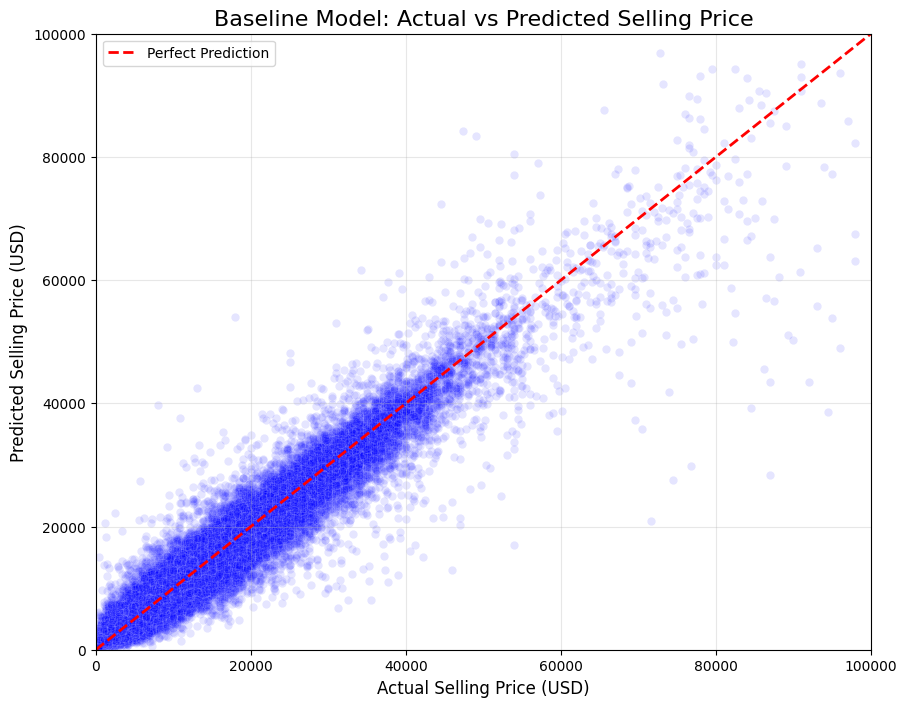

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Use a scatter plot with high transparency (alpha) to handle dense data points
sns.scatterplot(x=y_test, y=np.expm1(lgbm_preds_log), alpha=0.1, color="blue")

# Add a red diagonal line showing where "Perfect Predictions" would fall
max_val = min(y_test.max(), 100000) # Cap the chart at 100k for readability
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# Formatting
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.title('Baseline Model: Actual vs Predicted Selling Price', fontsize=16)
plt.xlabel('Actual Selling Price (USD)', fontsize=12)
plt.ylabel('Predicted Selling Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

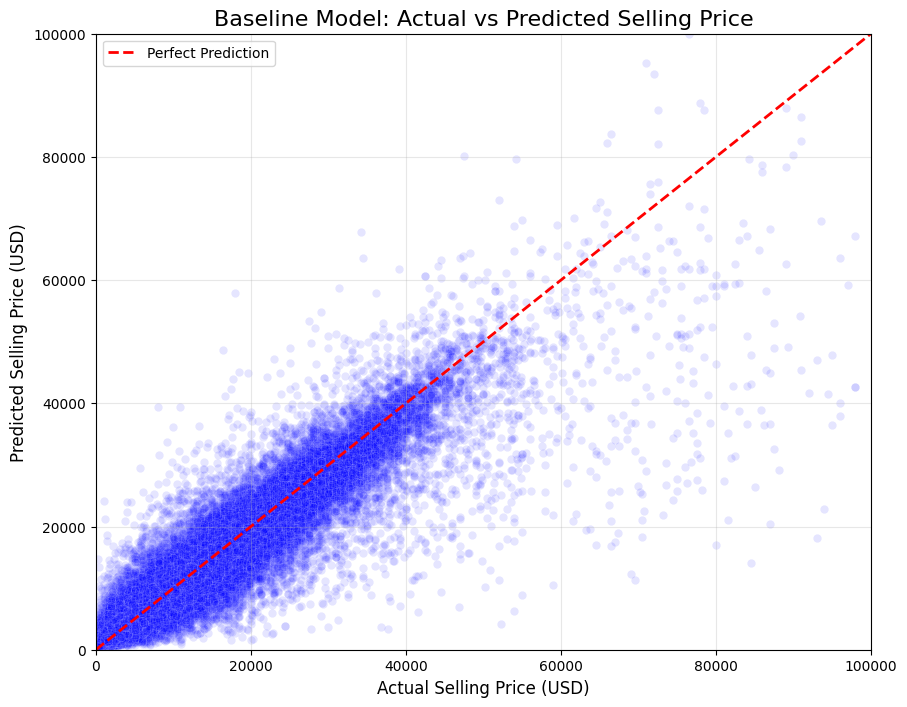

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Use a scatter plot with high transparency (alpha) to handle dense data points
sns.scatterplot(x=y_test, y=np.expm1(lgbm_preds_log), alpha=0.1, color="blue")

# Add a red diagonal line showing where "Perfect Predictions" would fall
max_val = min(y_test.max(), 100000) # Cap the chart at 100k for readability
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# Formatting
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.title('Baseline Model: Actual vs Predicted Selling Price', fontsize=16)
plt.xlabel('Actual Selling Price (USD)', fontsize=12)
plt.ylabel('Predicted Selling Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

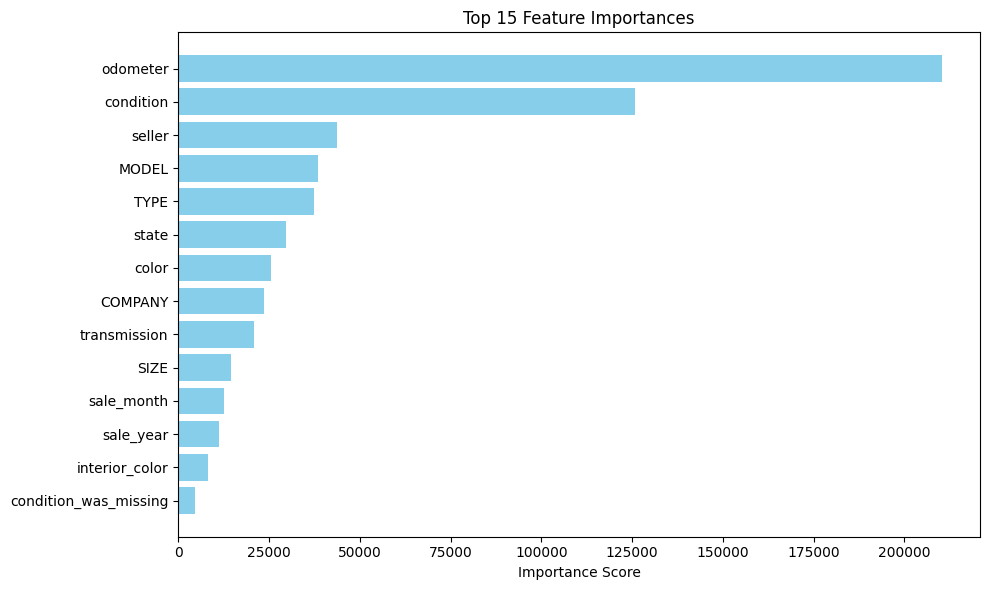

In [42]:
import matplotlib.pyplot as plt

# Change to lgbm if LightGBM performs better
best_model = lgbm 

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'][::-1], importance['Importance'][::-1], color='skyblue')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

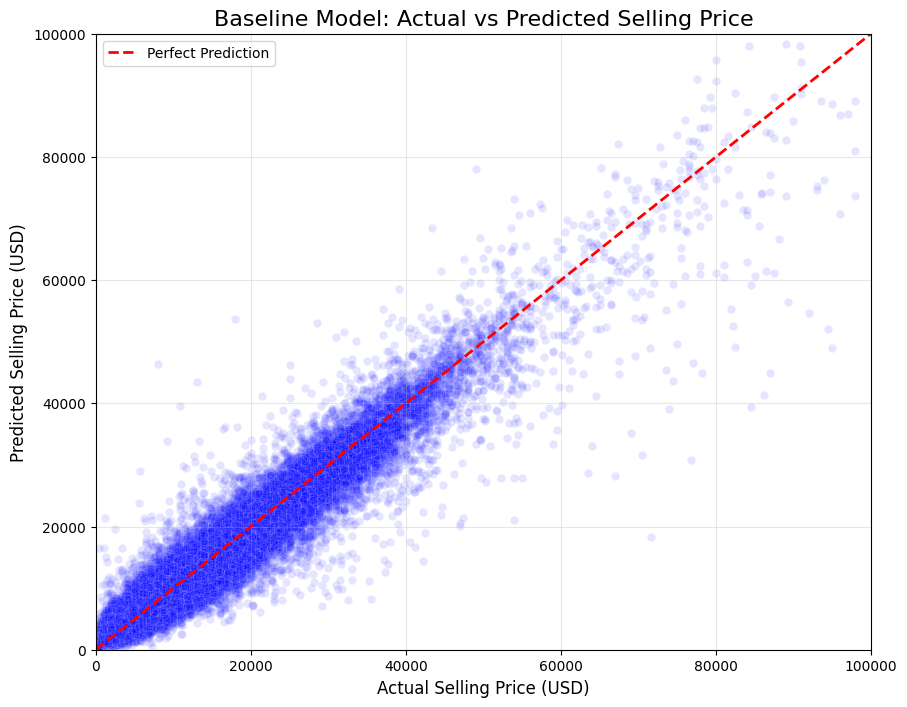

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Use a scatter plot with high transparency (alpha) to handle dense data points
sns.scatterplot(x=y_test, y=np.expm1(xgb_preds_log), alpha=0.1, color="blue")

# Add a red diagonal line showing where "Perfect Predictions" would fall
max_val = min(y_test.max(), 100000) # Cap the chart at 100k for readability
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# Formatting
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.title('Baseline Model: Actual vs Predicted Selling Price', fontsize=16)
plt.xlabel('Actual Selling Price (USD)', fontsize=12)
plt.ylabel('Predicted Selling Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

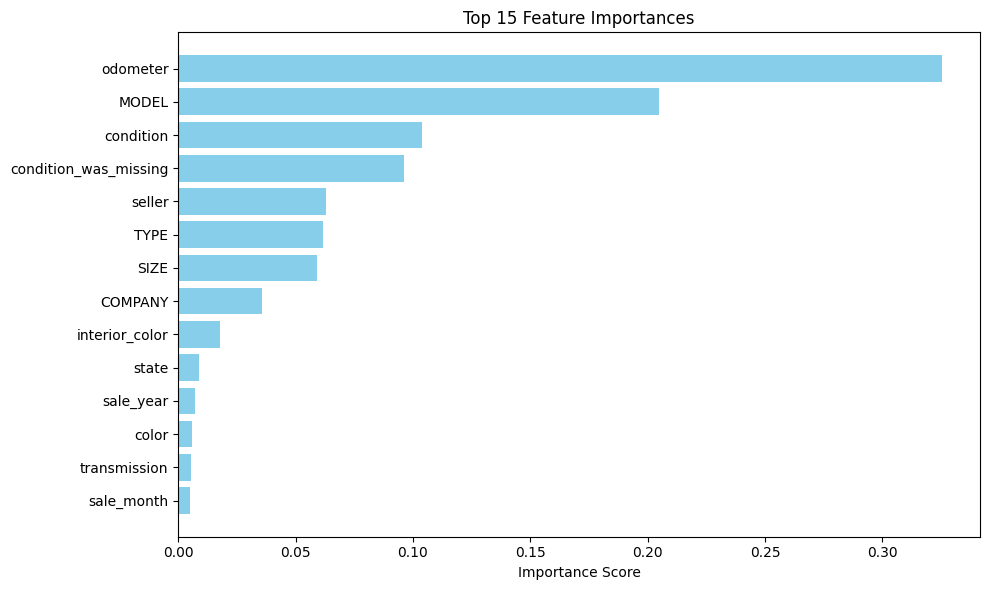

In [45]:
import matplotlib.pyplot as plt

# Change to lgbm if LightGBM performs better
best_model = xgb 

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'][::-1], importance['Importance'][::-1], color='skyblue')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
import optuna
from sklearn.metrics import mean_squared_error

# Create a validation set exclusively for Optuna to avoid touching X_test
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
def deduplicate_columns(columns):
    seen = set()
    new_columns = []
    for col in columns:
        new_col = col
        count = 1
        # If the column name already exists, append a number until it's unique
        while new_col in seen:
            new_col = f"{col}_{count}"
            count += 1
        seen.add(new_col)
        new_columns.append(new_col)
    return new_columns

# Apply to both train and test sets
X_tr.columns = deduplicate_columns(X_tr.columns)
X_val.columns = deduplicate_columns(X_val.columns)

# Log-transform targets once to save computation time inside the loops
y_tr_log = np.log1p(y_tr)
y_val_log = np.log1p(y_val)

In [20]:
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor, early_stopping

def objective_lgbm(trial):
    # 1. Define the hyperparameter search space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 5000),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        
        # Hardcode to 1.0 to ensure every column is available to every tree
        'colsample_bytree': trial.suggest_float('subsample', 0.5, 1.0), 
        
        # --- Crucial for Dummified / Sparse Data ---
        # Allows splits on rare dummy categories
        'min_child_samples': trial.suggest_int('min_child_samples', 2, 100), 
        # L1 regularization pushes weights of useless dummy columns to 0
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True), 
        # L2 regularization prevents overfitting on sparse data
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True), 
        
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1 # Suppress LightGBM warnings
    }
    
    # 2. Initialize the model
    model = LGBMRegressor(**params)
    
    # Fit with Early Stopping to save hours of compute time
    model.fit(
        X_tr, y_tr_log,
        eval_set=[(X_val, y_val_log)],
        # Stop if validation RMSE doesn't improve for 50 rounds
        callbacks=[early_stopping(stopping_rounds=100, verbose=False)] 
    )
    
    # 3. Predict and calculate RMSE
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val_log, preds))
    
    return rmse

print("Starting LightGBM Optuna Study...")
study_lgbm = optuna.create_study(direction='minimize', study_name="LGBM_Tuning")
study_lgbm.optimize(objective_lgbm, n_trials=50)

print("\nBest LightGBM Parameters:")
print(study_lgbm.best_params)
print(f"Best LightGBM RMSE (Log Scale): {study_lgbm.best_value:.4f}")

[I 2026-07-30 10:41:41,521] A new study created in memory with name: LGBM_Tuning


Starting LightGBM Optuna Study...


[I 2026-07-30 10:42:00,431] Trial 0 finished with value: 0.3513053712763398 and parameters: {'n_estimators': 3673, 'max_depth': 10, 'learning_rate': 0.011220213142463933, 'num_leaves': 30, 'subsample': 0.8844872628579015, 'min_child_samples': 88, 'reg_alpha': 0.6788057351058953, 'reg_lambda': 4.585646581438743e-08}. Best is trial 0 with value: 0.3513053712763398.
[I 2026-07-30 10:42:09,417] Trial 1 finished with value: 0.38675738024560363 and parameters: {'n_estimators': 1987, 'max_depth': 5, 'learning_rate': 0.012079129041543646, 'num_leaves': 143, 'subsample': 0.5757913959025895, 'min_child_samples': 25, 'reg_alpha': 0.003091492797780568, 'reg_lambda': 0.09132129292434735}. Best is trial 0 with value: 0.3513053712763398.
[I 2026-07-30 10:42:22,855] Trial 2 finished with value: 0.34920001480089813 and parameters: {'n_estimators': 2305, 'max_depth': 8, 'learning_rate': 0.01797907889394168, 'num_leaves': 135, 'subsample': 0.6414803779836264, 'min_child_samples': 58, 'reg_alpha': 0.00243


Best LightGBM Parameters:
{'n_estimators': 4604, 'max_depth': 11, 'learning_rate': 0.04928392740074465, 'num_leaves': 133, 'subsample': 0.7067879053047793, 'min_child_samples': 7, 'reg_alpha': 5.866342158074236e-05, 'reg_lambda': 1.8106931104542093e-07}
Best LightGBM RMSE (Log Scale): 0.3220


In [25]:
import optuna
import numpy as np
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

def objective_xgb(trial):
    # 1. Define the hyperparameter search space (Translated for XGBoost)
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 5000),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        
        # Note: Fixed the copy-paste typo from the LGBM params 
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0), 
        
        # --- Leaf-wise growth equivalent to LightGBM's num_leaves ---
        'max_leaves': trial.suggest_int('max_leaves', 20, 150),
        'grow_policy': 'lossguide', 
        'tree_method': 'hist', # Critical for speed on 700+ columns
        
        # --- Crucial for Dummified / Sparse Data ---
        # XGBoost equivalent of min_child_samples
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 100),
        
        # Regularization (helps push useless dummy columns to 0)
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True), 
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True), 
        
        # Built-in early stopping so you don't actually run 5000 trees if it stops improving
        'early_stopping_rounds': 50,
        
        'random_state': 42,
        'n_jobs': -1
    }
    
    # 2. Initialize the model
    model = XGBRegressor(**params)
    
    # 3. Fit the model (eval_set is required since early_stopping_rounds is set)
    model.fit(
        X_tr, y_tr_log,
        eval_set=[(X_val, y_val_log)],
        verbose=False # Suppress training logs per tree
    )
    
    # 4. Predict and calculate RMSE
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val_log, preds))
    
    return rmse

print("Starting XGBoost Optuna Study...")
study_xgb = optuna.create_study(direction='minimize', study_name="XGB_Tuning")
study_xgb.optimize(objective_xgb, n_trials=20) 

print("\nBest XGBoost Parameters:")
print(study_xgb.best_params)
print(f"Best XGBoost RMSE (Log Scale): {study_xgb.best_value:.4f}")

[I 2026-07-30 11:14:07,384] A new study created in memory with name: XGB_Tuning


Starting XGBoost Optuna Study...


[I 2026-07-30 11:14:42,053] Trial 0 finished with value: 0.3465644637110014 and parameters: {'n_estimators': 724, 'max_depth': 5, 'learning_rate': 0.18383962493580894, 'subsample': 0.731587693430736, 'colsample_bytree': 0.9673900702157053, 'max_leaves': 130, 'min_child_weight': 16, 'reg_alpha': 9.789755633374838, 'reg_lambda': 0.9337307944188381}. Best is trial 0 with value: 0.3465644637110014.
[I 2026-07-30 11:15:55,112] Trial 1 finished with value: 0.329188309036806 and parameters: {'n_estimators': 1973, 'max_depth': 12, 'learning_rate': 0.10005953418128376, 'subsample': 0.5535537935782959, 'colsample_bytree': 0.7396619442163646, 'max_leaves': 149, 'min_child_weight': 26, 'reg_alpha': 1.6658953618563576e-08, 'reg_lambda': 3.2872425989522713}. Best is trial 1 with value: 0.329188309036806.
[I 2026-07-30 11:16:55,558] Trial 2 finished with value: 0.36895720717305736 and parameters: {'n_estimators': 1028, 'max_depth': 11, 'learning_rate': 0.015450278073143257, 'subsample': 0.82898502932


Best XGBoost Parameters:
{'n_estimators': 2837, 'max_depth': 11, 'learning_rate': 0.05313334560502999, 'subsample': 0.7608577849815158, 'colsample_bytree': 0.8057054530799598, 'max_leaves': 57, 'min_child_weight': 4, 'reg_alpha': 2.076002938906018e-06, 'reg_lambda': 0.0004671606283806984}
Best XGBoost RMSE (Log Scale): 0.3244


In [30]:
# Example: Retraining the best LightGBM model
print("Retraining LightGBM with optimal hyperparameters...")

best_lgbm_params = study_lgbm.best_params
# Add back the static parameters that Optuna didn't tune
best_lgbm_params['random_state'] = 42
best_lgbm_params['n_jobs'] = -1

final_lgbm = LGBMRegressor(**best_lgbm_params)
final_lgbm.fit(X_train, np.log1p(y_train))

final_preds = final_lgbm.predict(X_test)
evaluate("Optimized LightGBM", y_test, final_preds)

Retraining LightGBM with optimal hyperparameters...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007997 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6346
[LightGBM] [Info] Number of data points in the train set: 405806, number of used features: 14
[LightGBM] [Info] Start training from score 9.216023
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [33]:
# Example: Retraining the best XGBoost model
print("Retraining XGBoost with optimal hyperparameters...")

best_xgb_params = study_xgb.best_params

# Add back the static parameters that Optuna didn't tune
best_xgb_params['random_state'] = 42
best_xgb_params['n_jobs'] = -1
best_xgb_params['enable_categorical'] = True  # CRUCIAL: Must be added back!

# Pass the correct dictionary (best_xgb_params, not best_lgbm_params)
final_xgb = XGBRegressor(**best_xgb_params)
final_xgb.fit(X_train, np.log1p(y_train))

final_preds = final_xgb.predict(X_test)

# Update the label so your printout makes sense
evaluate("Optimized XGBoost", y_test, final_preds)

Retraining XGBoost with optimal hyperparameters...
--- Optimized XGBoost ---
R²:   0.9397
RMSE: 2,364.62
MAE:  1,419.24

